# Importación

In [68]:
import pandas as pd

In [69]:
edges = pd.read_csv("edges.csv")
stations = pd.read_csv("stations.csv")

# Limpieza y QA

In [70]:
print("Se identificaron estaciones redundantes")
stations[stations["code"].duplicated(keep=False)]

Se identificaron estaciones redundantes


,code,lat,long,name
814,EPH,51.49409,-0.09951,Elephant & Castle
815,EPH,51.49409,-0.09951,Elephant and Castle Und


In [71]:
stations = stations.drop_duplicates(subset=["code"], keep="first").reset_index(drop=True)
stations

,code,lat,long,name
0,AAP,51.598290,-0.120140,Alexandra Palace
1,AAT,57.609813,-4.914217,Achanalt
2,ABA,51.715057,-3.443099,Aberdare
3,ABC,58.388326,-3.705268,Altnabreac
4,ABD,57.143048,-2.097480,Aberdeen
...,...,...,...,...
2575,YVJ,50.924729,-2.613179,Yeovil Junction
2576,YVP,50.944512,-2.613439,Yeovil Pen Mill
2577,ZCW,51.498231,-0.050791,Canada Water
2578,ZFD,51.520530,-0.105040,Farringdon


In [72]:
print("Se valida que todas no están conectadas con todas")
edges.source.value_counts()

Se valida que todas no están conectadas con todas


,count
source,
LDS,24
BHM,23
GLC,22
RDG,20
NOT,20
...,...
AYW,1
AVP,1
ALO,1


# Mini EDA

In [73]:
# Given the dataframe "edges" and the columns "lat" and "long" make a graph of each datapoint
import plotly.express as px



In [74]:
fig = px.scatter_mapbox(stations, lat="lat", lon="long", hover_name="name", title="Station Locations", mapbox_style="open-street-map")
fig.show()

# Make Graph Class from scracth

In [75]:
class Node():
  def __init__(self, pseud, full_name=None, lat=None, long=None):
    self.pseud = pseud
    self.full_name = full_name
    self.lat = lat
    self.long = long

class Graph():
  def __init__(self):
    self.nodes = {}
    self.adj_list = {}

  def add_node(self, node: Node):
    self.nodes[node.pseud] = node
    self.adj_list[node.pseud] = {}
    return node

  def add_edge(self, source: Node, target: Node, weight=1, dir=False):
    self.adj_list[source.pseud][target.pseud] = weight
    if not dir: self.adj_list[target.pseud][source.pseud] = weight
    return self.adj_list

In [76]:
g = Graph()
for index, row in stations.iterrows():
  g.add_node(Node(row["code"], row["name"], row["lat"], row["long"]))
for index, row in edges.iterrows():
  g.add_edge(g.nodes[row["source"]], g.nodes[row["target"]], weight=row["distance"], dir=True)

In [77]:
g.adj_list

{'AAP': {'BOP': 1.0, 'HRN': 1.43, 'NSG': 2.37, 'PAL': 2.38},
 'AAT': {'ACN': 10.03, 'LCC': 6.36},
 'ABA': {'CMH': 2.5},
 'ABC': {'FRS': 11.71, 'SCT': 13.8},
 'ABD': {'DYC': 9.01, 'MTS': 52.98, 'PLN': 9.25, 'STN': 21.07},
 'ABE': {'CPH': 0.87, 'ECP': 0.98, 'LNB': 3.15},
 'ABH': {'PNC': 2.43, 'PWL': 3.09},
 'ABW': {'BNH': 4.03, 'BVD': 2.2, 'PLU': 2.5, 'SGR': 5.49, 'WWC': 3.36},
 'ABY': {'BLV': 1.38, 'GTO': 1.82, 'GUI': 5.35, 'MAN': 2.37},
 'ACB': {'HTF': 4.23, 'RUN': 12.16},
 'ACC': {'SAT': 1.11, 'WIJ': 2.95},
 'ACG': {'BMO': 5.98, 'OLT': 1.56, 'TYS': 1.46},
 'ACH': {'ACN': 18.94, 'STC': 8.74},
 'ACK': {'ALM': 9.54, 'WDD': 7.65},
 'ACL': {'GYM': 12.21, 'LGD': 3.9},
 'ACN': {'AAT': 10.03, 'ACH': 18.94},
 'ACR': {'BBN': 7.22, 'BYM': 8.71, 'CTW': 1.41, 'HCT': 2.64, 'RSG': 6.87},
 'ACT': {'BAG': 4.74, 'MAO': 3.39, 'SNG': 3.37},
 'ACY': {'PER': 3.61, 'PPD': 5.14, 'QYD': 1.8},
 'ADC': {'PRB': 3.02, 'PYT': 3.43},
 'ADD': {'BHM': 2.92, 'SCF': 3.05},
 'ADK': {'ABY': 1.3},
 'ADL': {'BLK': 3.25, 'C

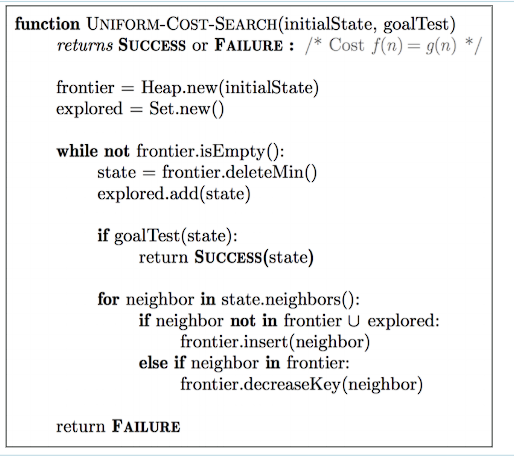

In [78]:
class PriorityQueue():
  def __init__(self):
    self.queue = []

  def get_items(self):
    return [i[0] for i in self.queue]

  def push(self, value, priority):
    self.queue.append((value, priority))

  def __sort(self):
    self.queue = sorted(self.queue, key=lambda x: x[1])

  def pop(self):
    self.__sort()
    return self.queue.pop(0)

  def decrease_key(self, value, possible_new_priority):
    done = False
    for i in range(len(self.queue)):
      if self.queue[i][0] == value:
        if self.queue[i][1] > possible_new_priority:
          self.queue[i] = (value, possible_new_priority)
          done = True
    return done

In [79]:
class UCSSolver():

  @staticmethod
  def backtrack(parents, target, source):
    path = [target]
    while target != source:
      target = parents[target]
      path.append(target)
    path.append(target)
    return path[::-1][1:]

  @staticmethod
  def solve(g, source: str, target: str):

    parents = {}

    frontier = PriorityQueue()
    frontier.push(source, 0)
    explored = set()

    while not len(frontier.queue) == 0:
      current, curr_dist = frontier.pop()
      explored.add(current)
      if current == target:
        return curr_dist, UCSSolver.backtrack(parents, target, source)
      for neighbor, dist in g.adj_list[current].items():
        if neighbor not in explored and neighbor not in frontier.get_items():
          frontier.push(neighbor, curr_dist+dist)
          parents[neighbor] = current
        elif neighbor in frontier.get_items():
          decreased = frontier.decrease_key(neighbor, curr_dist+dist)
          if decreased: parents[neighbor] = current

    return False

In [83]:
def find_node_by_full_name(g, target_name):
  for node in g.nodes.values():
    if node.full_name == target_name:
      return node

node1 = find_node_by_full_name(g, "Bingham").pseud
node2 = find_node_by_full_name(g, "Lincoln").pseud

best_dist, best_route = UCSSolver.solve(g, node1, node2)
print(f"Finding best route from {node1} to {node2}")
best_dist, best_route

Finding best route from BIN to LCN


(64.86, ['BIN', 'NOT', 'NCT', 'CLM', 'LCN'])

In [84]:
def find_route_length_by_pseuds(g, pseuds):
  total_dist = 0
  for i in range(len(pseuds)-1):
    total_dist += g.adj_list[pseuds[i]][pseuds[i+1]]
  return total_dist

In [85]:
find_route_length_by_pseuds(g, best_route)

64.86